In [1]:
import pandas as pd

df = pd.read_csv("data/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Titanic Exploratory Data Analysis

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the Titanic dataset. The objective is to understand the dataset, clean missing values, analyze passenger characteristics, and identify factors that influenced survival. The notebook follows a reproducible workflow using Python, Pandas, Matplotlib, and Seaborn.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set plot style
plt.style.use("ggplot")

## Load the Dataset

The Titanic dataset is loaded using a relative file path. Using a relative path ensures that the notebook can be executed on any computer without modifying the code.

In [5]:
df = pd.read_csv("data/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

Before cleaning the data, we examine its structure, data types, summary statistics, and missing values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.shape

(891, 12)

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

The dataset contains missing values in the Age, Cabin, and Embarked columns.

Cleaning decisions:

- Age is filled using the median because it is less affected by extreme values.
- Cabin is removed because most of its values are missing.
- Embarked is filled with the most frequent category.

In [11]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df.drop(columns=["Cabin"], inplace=True)

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Exploratory Data Analysis

The following visualizations help identify patterns in passenger survival based on different features.

## 1. Survival Count

This graph shows the number of passengers who survived and those who did not.


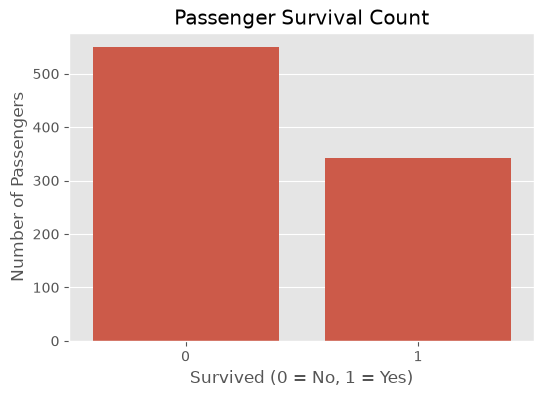

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:**

More passengers died than survived during the Titanic disaster.

## 2. Survival by Gender

This graph compares survival between male and female passengers.

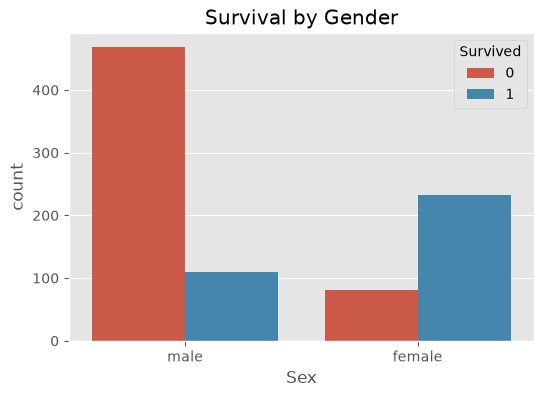

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.show()

**Observation:**

Female passengers had a much higher survival rate than male passengers.

## 3. Survival by Passenger Class

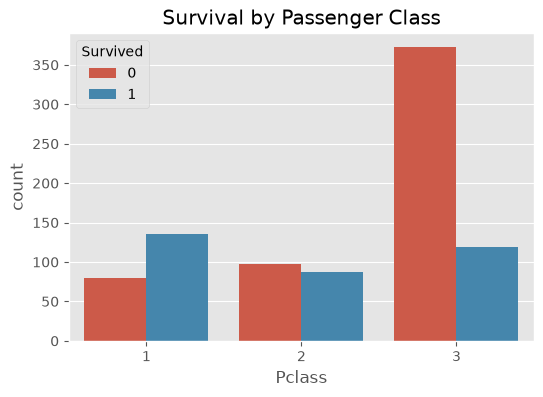

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()

**Observation:**

First-class passengers survived more often than second- and third-class passengers.

## 4. Age Distribution

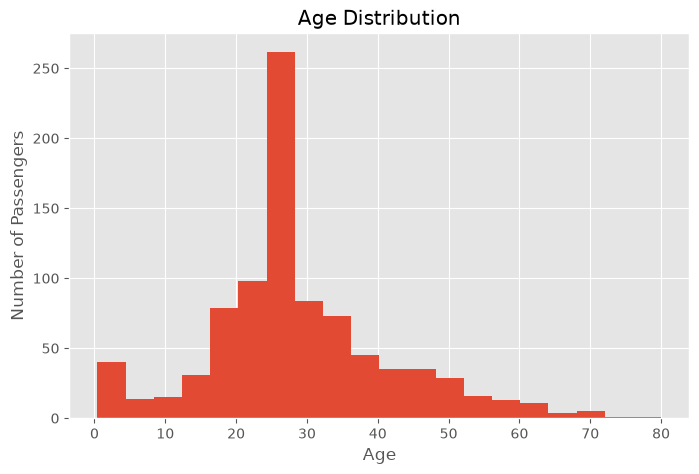

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:**

Most passengers were between 20 and 40 years old.

## 5. Fare Distribution

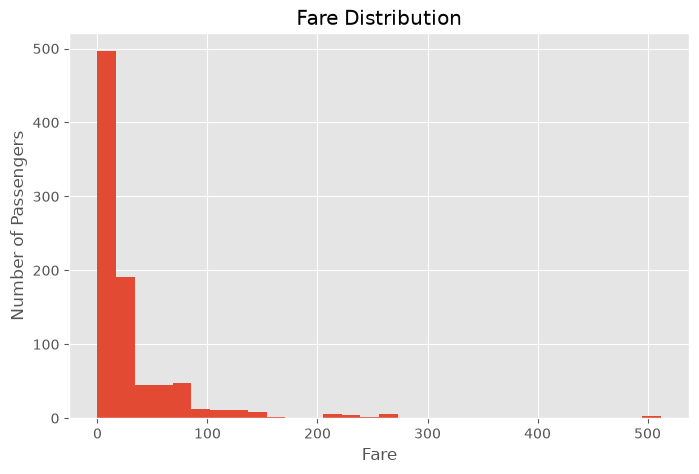

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Fare"], bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

**Observation:**

Most passengers paid low fares, while only a few paid very high ticket prices.

## 6. Correlation Heatmap

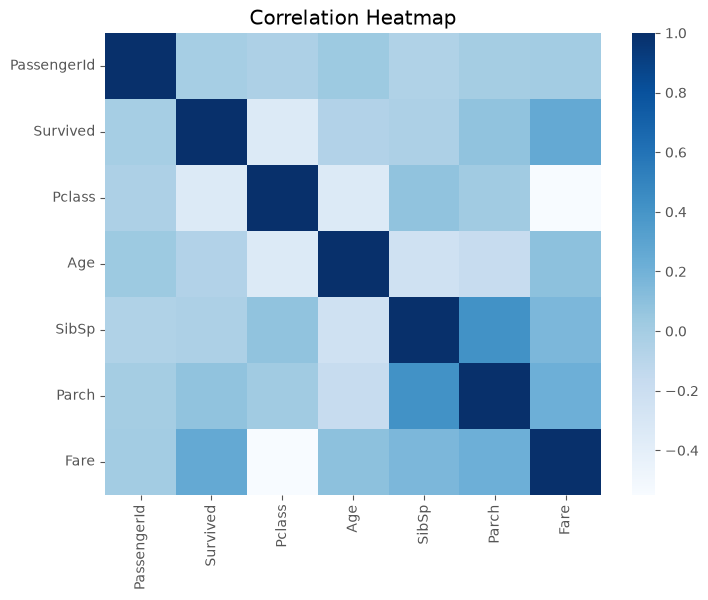

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=False,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

**Observation:**

Passenger Class has a noticeable relationship with survival, while Age shows a weaker correlation.

## 7. Age vs Fare

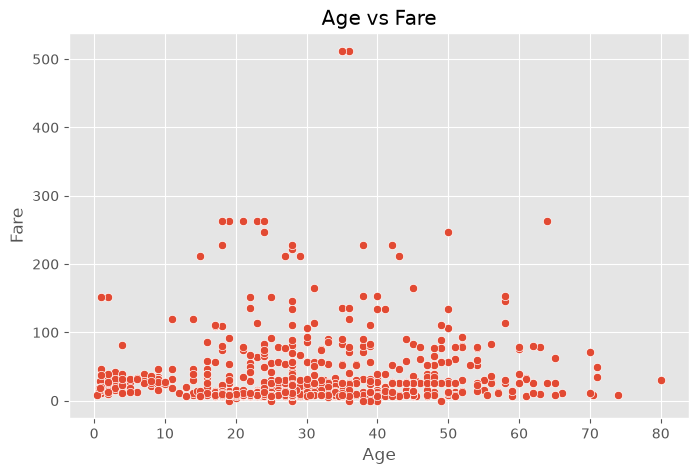

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Fare",
    data=df
)

plt.title("Age vs Fare")

plt.show()

**Observation:**

Passengers who paid higher fares belonged to different age groups, indicating no strong relationship between age and ticket fare.

# Findings

The exploratory data analysis of the Titanic dataset shows that gender and passenger class were the two most important factors affecting survival. Female passengers had a much higher chance of surviving than male passengers, reflecting the rescue priority given to women during the disaster. Passengers traveling in first class also had significantly better survival rates compared to those in second and third class, suggesting that socioeconomic status influenced access to lifeboats. The Age distribution shows that most passengers were between 20 and 40 years old, but age alone did not strongly determine survival. The Fare distribution was highly skewed because a small number of passengers paid much higher ticket prices. Missing values in the Age and Embarked columns were handled using the median and mode, while the Cabin column was removed because it contained too many missing values. Overall, gender and passenger class had the strongest influence on passenger survival.